# Goal: produce a dataframe linking each storm report to the nearest ETC node, preserving everything needed for downstream synoptic compositing and mesoscale KDE work. 

In [4]:
### Importing necessary packages
import pandas as pd
import os
from pathlib import Path
import re
import warnings
#warnings.filterwarnings('ignore')
import matplotlib 
import matplotlib.pyplot as plt
import matplotlib.colors as col
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import cmocean
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np
import seaborn as sns
import xarray as xr

##Add more as needed
## custom packages
from stormevents_utils import standardize_and_convert_to_utc, build_begin_datetime, load_stormevents_data
from TE_processing import parse_nodefile, filter_tracks

### Load in storm data:

In [2]:
# Loading in the storm report data
data_dir = Path("/data1/lepique/stormevents_details/")  

df_scs = load_stormevents_data(data_dir)

## Subsetting winter months:
winter_season = {12, 1, 2, 3}
df_winter_scs = df_scs[df_scs["BEGIN_DT_UTC"].dt.month.isin(winter_season)]

df_winter_scs_subset = df_winter_scs[
    (df_winter_scs["WINTER_SEASON"] >= 1996) & (df_winter_scs["WINTER_SEASON"] <= 2025)
]

Found 76 files
Reading StormEvents_details-ftp_v1.0_d1950_c20250520.csv.gz (year=1950)
Reading StormEvents_details-ftp_v1.0_d1951_c20250520.csv.gz (year=1951)
Reading StormEvents_details-ftp_v1.0_d1952_c20250520.csv.gz (year=1952)
Reading StormEvents_details-ftp_v1.0_d1953_c20250520.csv.gz (year=1953)
Reading StormEvents_details-ftp_v1.0_d1954_c20250520.csv.gz (year=1954)
Reading StormEvents_details-ftp_v1.0_d1955_c20250520.csv.gz (year=1955)
Reading StormEvents_details-ftp_v1.0_d1956_c20250520.csv.gz (year=1956)
Reading StormEvents_details-ftp_v1.0_d1957_c20250520.csv.gz (year=1957)
Reading StormEvents_details-ftp_v1.0_d1958_c20250520.csv.gz (year=1958)
Reading StormEvents_details-ftp_v1.0_d1959_c20250520.csv.gz (year=1959)
Reading StormEvents_details-ftp_v1.0_d1960_c20250520.csv.gz (year=1960)
Reading StormEvents_details-ftp_v1.0_d1961_c20250520.csv.gz (year=1961)
Reading StormEvents_details-ftp_v1.0_d1962_c20250520.csv.gz (year=1962)
Reading StormEvents_details-ftp_v1.0_d1963_c20250

Reading StormEvents_details-ftp_v1.0_d2021_c20250520.csv.gz (year=2021)
Reading StormEvents_details-ftp_v1.0_d2022_c20250721.csv.gz (year=2022)
Reading StormEvents_details-ftp_v1.0_d2023_c20260116.csv.gz (year=2023)
Reading StormEvents_details-ftp_v1.0_d2024_c20260116.csv.gz (year=2024)
Reading StormEvents_details-ftp_v1.0_d2025_c20260116.csv.gz (year=2025)
Done.
(1062752, 55)
EVENT_TYPE
Thunderstorm Wind    563660
Hail                 418824
Tornado               80268
Name: count, dtype: int64
1950 2025


In [3]:
df_winter_scs_subset

,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,BEGIN_DT,WINTER_SEASON,SOURCE_FILE_YEAR,BEGIN_DT_UTC
244480,199612,1,700,199612,1,700,2052317.0,5571120,GEORGIA,13.0,...,-85.0500,31.6000,-85.0500,A few trees were blown down across the county ...,NaN,PDC,1996-12-01 07:00:00,1997,1996,1996-12-01 12:00:00+00:00
244481,199612,1,700,199612,1,700,2052318.0,5571121,GEORGIA,13.0,...,-84.8200,31.7800,-84.8200,The sheriff's office reported several trees do...,NaN,PDC,1996-12-01 07:00:00,1997,1996,1996-12-01 12:00:00+00:00
244482,199612,1,705,199612,1,705,2052319.0,5571122,GEORGIA,13.0,...,-84.4500,31.7700,-84.4500,County sheriff's office reported a few trees b...,NaN,PDC,1996-12-01 07:05:00,1997,1996,1996-12-01 12:05:00+00:00
244483,199612,7,430,199612,7,430,1026645.0,5571123,FLORIDA,12.0,...,-84.6500,30.1800,-84.6500,Several trees were blown down and 2 mobile hom...,NaN,PDC,1996-12-07 04:30:00,1997,1996,1996-12-07 09:30:00+00:00
244485,199612,1,1345,199612,1,1345,1029765.0,5577054,PENNSYLVANIA,42.0,...,-80.3700,41.7500,-80.3700,A wind gust of 60 miles per hour was reported.,NaN,PDC,1996-12-01 13:45:00,1997,1996,1996-12-01 18:45:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1056239,202503,30,2320,202503,30,2320,206867.0,1290825,KENTUCKY,21.0,...,-83.3841,38.1571,-83.3841,A deep low pressure system (including a surfac...,Powerlines were reported to have blown down at...,CSV,2025-03-30 23:20:00,2025,2025,2025-03-31 03:20:00+00:00
1056240,202503,31,20,202503,31,20,206867.0,1290828,KENTUCKY,21.0,...,-83.7779,37.1871,-83.7779,A deep low pressure system (including a surfac...,A tree was reported to have been blown down ne...,CSV,2025-03-31 00:20:00,2025,2025,2025-03-31 04:20:00+00:00
1056244,202503,31,119,202503,31,119,206867.0,1290851,KENTUCKY,21.0,...,-82.5863,37.3389,-82.5863,A deep low pressure system (including a surfac...,Powerlines were reported to have been blown do...,CSV,2025-03-31 01:19:00,2025,2025,2025-03-31 05:19:00+00:00
1056246,202503,27,200,202503,27,200,200858.0,1249986,TEXAS,48.0,...,-97.1590,26.0711,-97.1590,Several rounds of showers and thunderstorms pu...,"The C-MAN station at Brazos Santiago, just ins...",CSV,2025-03-27 02:00:00,2025,2025,2025-03-27 07:00:00+00:00


In [ ]:
# df_winter_scs_2020 = df_winter_scs[df_winter_scs["WINTER_SEASON"] == 2020]
# df_winter_scs_2020 = df_winter_scs_2020[df_winter_scs_2020['BEGIN_DT'].dt.month.isin({1,2,3})]
# df_winter_scs_2020 = df_winter_scs_2020[
#     (
#         (df_winter_scs_2020['EVENT_TYPE'] == 'Thunderstorm Wind') & 
#         (df_winter_scs_2020['MAGNITUDE'] >= 65)
#     )
#     |
#     (
#         (df_winter_scs_2020['EVENT_TYPE'] == 'Hail') & 
#         (df_winter_scs_2020['MAGNITUDE'] >= 2.0)
#     )
#     |
#     (
#         (df_winter_scs_2020['EVENT_TYPE'] == 'Tornado') & 
#         (df_winter_scs_2020['MAGNITUDE'] >= 2)
#     )
# ]

### Load in track data

In [5]:
## Loading in the ETC track data:
tracks = parse_nodefile('/data1/lepique/TempestExtremes/tracks/tracks_hourly_1995_2025.txt')
#tracks = parse_nodefile('/data1/lepique/era5_test/trajsens2.ERA5.hourly_kiefer.txt')

tracks = filter_tracks(tracks)

In [6]:
tracks

,track_id,lon,lat,msl,z,year,month,day,hour,datetime
0,1,216.50,58.50,983.2175,1.946871,1995,12,1,0,1995-12-01 00:00:00
1,1,216.50,58.50,983.3931,1.946871,1995,12,1,1,1995-12-01 01:00:00
2,1,216.50,58.00,983.2056,3.209567,1995,12,1,2,1995-12-01 02:00:00
3,1,216.50,57.75,983.0194,0.650716,1995,12,1,3,1995-12-01 03:00:00
4,1,216.50,57.75,982.8556,0.650716,1995,12,1,4,1995-12-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...
829826,6119,230.25,43.75,997.9506,-2.805962,2025,3,31,19,2025-03-31 19:00:00
829827,6119,238.00,51.00,998.4312,1339.003000,2025,3,31,20,2025-03-31 20:00:00
829828,6119,238.00,51.00,997.7369,1339.003000,2025,3,31,21,2025-03-31 21:00:00
829837,6120,246.25,40.00,998.7162,1632.444000,2025,3,31,22,2025-03-31 22:00:00


In [ ]:
# tracks = tracks[tracks['month'].isin({1,2,3})]
# tracks = tracks[tracks['year'] == 2020]

In [6]:
tracks['datetime'].dt.hour.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23], dtype=int32)

## Pre-processing helpers

In [5]:
## PROCESSING TRACK DATA
def prep_tracks(tracks):
    tracks_h = tracks.copy()
    ## convert longitude to -180 to 180 to match storm reports
    tracks_h['lon'] = ((tracks['lon'] + 180) % 360) - 180

    ## rename datetime to time hour
    tracks_h = tracks_h.rename(columns={'datetime': 'time_hour'})
    tracks_h['time_hour'] = pd.to_datetime(tracks_h['time_hour']).dt.tz_localize('UTC')

    ## keep only columns we need
    tracks_h = tracks_h[['track_id','time_hour','lat','lon','msl']]

    ## Domain filter (even though there is already a filter, this'll drop individual nodes outside the domain)
    # tracks_h = tracks_h.loc[
    #     (tracks_h['lon'] >=135) & (tracks_h['lon'] <=-55) & 
    #     (tracks_h['lat'] >=20) & (tracks_h['lat'] <=70) 
    # ].copy()

    tracks_h = tracks_h.reset_index(drop=True)

    ## per track metadata
    ## Kiefer doesn't compute lifecycle metrics so this is new
    def _time_of_min_msl(sub: pd.Series) -> pd.Timestamp:
        """Return the hour at which msl is at a minimum for a given track
        """
        return tracks_h.loc[sub.index, 'time_hour'].iloc[
            tracks_h.loc[sub.index,'msl'].values.argmin()
        ]
    
    track_meta = (
        tracks_h.groupby('track_id')
        .agg(
            track_start = ('time_hour', 'min'),
            track_end = ('time_hour', 'max'),
            time_min_msl = ('time_hour', _time_of_min_msl),
            min_msl = ('msl', 'min'),
            n_steps = ('time_hour','size'),
        )
    )
    return tracks_h, track_meta

In [6]:
### PROCESSING REPORT DATA

def prep_reports(df_reports: pd.DataFrame) ->pd.DataFrame:
    """
    Clean and standardize the storm report data to enable merging with track data.
    """
    reports_h = df_reports.copy()

    ## ennsure datetime is a pd.datetime (though should be already)
    reports_h['BEGIN_DT_UTC'] = pd.to_datetime(reports_h['BEGIN_DT_UTC'])

    ## round to the nearest hour to match track data
    reports_h['time_hour'] = reports_h['BEGIN_DT_UTC'].dt.round('1h')

    ## rename lat/lon columns
    reports_h = reports_h.rename(columns={
        'BEGIN_LAT': 'report_lat',
        'BEGIN_LON': 'report_lon',
    })

    ## standardize lon to -180 to 180 (shouldn't be necessary but as a precaution)
    reports_h["report_lon"] = ((reports_h["report_lon"] + 180) % 360) - 180

    ## keep canonical columns first, carry rest
    core_cols = ['EVENT_ID','time_hour','report_lat','report_lon','EVENT_TYPE','BEGIN_DT_UTC']
    extra_cols = [c for c in reports_h.columns if c not in core_cols]
    reports_h = reports_h[core_cols + extra_cols].copy()

    ## drop reports with missing coordinates or EVENT_ID
    n_reports = len(reports_h)
    reports_h = reports_h.dropna(subset=['EVENT_ID','report_lat','report_lon'])
    n_dropped = n_reports - len(reports_h)
    if n_dropped:
        print(f'[prep_reports] Dropped {n_dropped} reports with missing ID or coords.')

    reports_h = reports_h.reset_index(drop=True)

    return reports_h

In [7]:
# Quick sanity-check helpers 
def check_prep_tracks(tracks_h: pd.DataFrame, track_meta: pd.DataFrame) -> None:
    """Print a basic QC summary for tracks_h and track_meta."""
    print("=== tracks_h ===")
    print(f"  Shape        : {tracks_h.shape}")
    print(f"  Date range   : {tracks_h.time_hour.min()} → {tracks_h.time_hour.max()}")
    print(f"  Lon range    : {tracks_h.lon.min():.2f} → {tracks_h.lon.max():.2f}")
    print(f"  Lat range    : {tracks_h.lat.min():.2f} → {tracks_h.lat.max():.2f}")
    print(f"  Unique tracks: {tracks_h.track_id.nunique()}")
    print(f"  Nulls        : {tracks_h.isnull().sum().to_dict()}")
    print()
    print("=== track_meta ===")
    print(f"  Shape              : {track_meta.shape}")
    print(f"  Track duration (h) : median={track_meta.n_steps.median():.0f}  max={track_meta.n_steps.max()}")
    print(f"  MSL range (hPa)    : {track_meta.min_msl.min():.1f} → {track_meta.min_msl.max():.1f}")
    print()
 
 
def check_prep_reports(reports_h: pd.DataFrame) -> None:
    """Print a basic QC summary for reports_h."""
    print("=== reports_h ===")
    print(f"  Shape        : {reports_h.shape}")
    print(f"  Date range   : {reports_h.time_hour.min()} → {reports_h.time_hour.max()}")
    print(f"  Lon range    : {reports_h.report_lon.min():.2f} → {reports_h.report_lon.max():.2f}")
    print(f"  Lat range    : {reports_h.report_lat.min():.2f} → {reports_h.report_lat.max():.2f}")
    print(f"  EVENT_TYPE   : {reports_h.EVENT_TYPE.value_counts().to_dict()}")
    print(f"  Nulls        : {reports_h.isnull().sum().to_dict()}")
    print()

In [8]:
tracks_h, tracks_meta = prep_tracks(tracks)

In [9]:
tracks_h

,track_id,time_hour,lat,lon,msl
0,179,1996-12-01 00:00:00+00:00,61.50,-28.00,968.1388
1,179,1996-12-01 01:00:00+00:00,61.50,-27.50,968.4262
2,179,1996-12-01 02:00:00+00:00,61.50,-26.50,968.2731
3,179,1996-12-01 03:00:00+00:00,61.75,-25.75,968.5244
4,179,1996-12-01 04:00:00+00:00,61.75,-24.75,968.7500
...,...,...,...,...,...
257018,6102,2025-03-31 19:00:00+00:00,43.75,-129.75,997.9506
257019,6102,2025-03-31 20:00:00+00:00,51.00,-122.00,998.4312
257020,6102,2025-03-31 21:00:00+00:00,51.00,-122.00,997.7369
257021,6103,2025-03-31 22:00:00+00:00,40.00,-113.75,998.7162


In [10]:
check_prep_tracks(tracks_h, tracks_meta)

=== tracks_h ===
  Shape        : (257023, 5)
  Date range   : 1996-12-01 00:00:00+00:00 → 2025-03-31 23:00:00+00:00
  Lon range    : -180.00 → 179.75
  Lat range    : 10.00 → 89.75
  Unique tracks: 2160
  Nulls        : {'track_id': 0, 'time_hour': 0, 'lat': 0, 'lon': 0, 'msl': 0}

=== track_meta ===
  Shape              : (2160, 5)
  Track duration (h) : median=94  max=618
  MSL range (hPa)    : 921.3 → 1017.3



In [11]:
reports_h = prep_reports(df_winter_scs_subset)

[prep_reports] Dropped 488 reports with missing ID or coords.


In [12]:
reports_h['time_hour']

0       1996-12-01 12:00:00+00:00
1       1996-12-01 12:00:00+00:00
2       1996-12-01 12:00:00+00:00
3       1996-12-07 10:00:00+00:00
4       1996-12-01 19:00:00+00:00
                   ...           
81591   2025-03-31 03:00:00+00:00
81592   2025-03-31 04:00:00+00:00
81593   2025-03-31 05:00:00+00:00
81594   2025-03-27 07:00:00+00:00
81595   2025-03-31 11:00:00+00:00
Name: time_hour, Length: 81596, dtype: datetime64[ns, UTC]

In [13]:
reports_h

,EVENT_ID,time_hour,report_lat,report_lon,EVENT_TYPE,BEGIN_DT_UTC,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,...,END_AZIMUTH,END_LOCATION,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,BEGIN_DT,WINTER_SEASON,SOURCE_FILE_YEAR
0,5571120,1996-12-01 12:00:00+00:00,31.6000,-85.0500,Thunderstorm Wind,1996-12-01 12:00:00+00:00,199612,1,700,199612,...,NaN,FT GAINES,31.6000,-85.0500,A few trees were blown down across the county ...,NaN,PDC,1996-12-01 07:00:00,1997,1996
1,5571121,1996-12-01 12:00:00+00:00,31.7800,-84.8200,Thunderstorm Wind,1996-12-01 12:00:00+00:00,199612,1,700,199612,...,NW,CUTHBERT,31.7800,-84.8200,The sheriff's office reported several trees do...,NaN,PDC,1996-12-01 07:00:00,1997,1996
2,5571122,1996-12-01 12:00:00+00:00,31.7700,-84.4500,Thunderstorm Wind,1996-12-01 12:05:00+00:00,199612,1,705,199612,...,NaN,DAWSON,31.7700,-84.4500,County sheriff's office reported a few trees b...,NaN,PDC,1996-12-01 07:05:00,1997,1996
3,5571123,1996-12-07 10:00:00+00:00,30.1800,-84.6500,Thunderstorm Wind,1996-12-07 09:30:00+00:00,199612,7,430,199612,...,NaN,SMITH CREEK,30.1800,-84.6500,Several trees were blown down and 2 mobile hom...,NaN,PDC,1996-12-07 04:30:00,1997,1996
4,5577054,1996-12-01 19:00:00+00:00,41.7500,-80.3700,Thunderstorm Wind,1996-12-01 18:45:00+00:00,199612,1,1345,199612,...,NaN,CONNEAUTVILLE,41.7500,-80.3700,A wind gust of 60 miles per hour was reported.,NaN,PDC,1996-12-01 13:45:00,1997,1996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81591,1290825,2025-03-31 03:00:00+00:00,38.1571,-83.3841,Thunderstorm Wind,2025-03-31 03:20:00+00:00,202503,30,2320,202503,...,ESE,BRADY,38.1571,-83.3841,A deep low pressure system (including a surfac...,Powerlines were reported to have blown down at...,CSV,2025-03-30 23:20:00,2025,2025
81592,1290828,2025-03-31 04:00:00+00:00,37.1871,-83.7779,Thunderstorm Wind,2025-03-31 04:20:00+00:00,202503,31,20,202503,...,WSW,BERNICE,37.1871,-83.7779,A deep low pressure system (including a surfac...,A tree was reported to have been blown down ne...,CSV,2025-03-31 00:20:00,2025,2025
81593,1290851,2025-03-31 05:00:00+00:00,37.3389,-82.5863,Thunderstorm Wind,2025-03-31 05:19:00+00:00,202503,31,119,202503,...,NNW,VIRGIE,37.3389,-82.5863,A deep low pressure system (including a surfac...,Powerlines were reported to have been blown do...,CSV,2025-03-31 01:19:00,2025,2025
81594,1249986,2025-03-27 07:00:00+00:00,26.0711,-97.1590,Thunderstorm Wind,2025-03-27 07:00:00+00:00,202503,27,200,202503,...,E,PORT ISABEL,26.0711,-97.1590,Several rounds of showers and thunderstorms pu...,"The C-MAN station at Brazos Santiago, just ins...",CSV,2025-03-27 02:00:00,2025,2025


## Matching Step (joining reports to ETC tracks)

In [14]:
def haversine(lat1: np.ndarray | float, 
              lon1: np.ndarray | float, 
              lat2: np.ndarray | float, 
              lon2: np.ndarray | float) -> np.ndarray:
    """
    Great circle distance in km between two sets of lat lon points. 
    All inputs in decimal degreesl arrays must be broadcast-compatible.
    Uses numerically stable two-arg arctan2 form.
    NOTE: Kiefer et al. calls geopy.distance.geodesic inside a Python while loop, one ETC candidate at a time.
    This version operates on entire columns at once.
    (could also use scikit learn haversine_distances)
    """
    R = 6371.0 # mean Earth radius (km)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

In [15]:
#### Merging reports and tracks

def match_reports_to_tracks(
        reports_h: pd.DataFrame,
        tracks_h: pd.DataFrame,
        max_dist_km: float = 2000.0,
        nw_dist_km: float = 500.0,
) -> pd.DataFrame:
    """
    Link each storm report to the nearest ETC node at the same hour,
    then apply the Kiefer et al. warm-sector proximity filter.

    Returns: 
    reports_tagged: pd.DataFrame
        reports_h with ETC columns appended
        Associated rows have: track_id, matched_time_hour, etc_lat,
        etc_lon, etc_msl, dist_km, rlon, rlat
        Unassociated rows have NaN for all ETC columns.
    """

    ## Step 1: Merge on time_hour
    pairs = reports_h.merge(
        tracks_h.rename(columns={'lat': 'etc_lat', 'lon': 'etc_lon', 'msl': 'etc_msl'}),
        on='time_hour',
        how='inner'
    )

    if pairs.empty:
        # no temporal overlap a all - return reports_h with NaN ETC cols.
        for col in ['track_id', 'etc_lat', 'etc_lon', 'etc_msl', 'dist_km', 'rlon', 'rlat']:
            reports_h[col] = np.nan
        return reports_h.copy()
    
    ## Step 2: compute great-circle distance for every pair
    pairs['dist_km'] = haversine(
        pairs['report_lat'].values, pairs['report_lon'].values,
        pairs['etc_lat'].values, pairs['etc_lon'].values,
    )

    ## Step 3: Quadrant offsets 
    pairs['rlon'] = pairs['report_lon'] - pairs['etc_lon']
    pairs['rlat'] = pairs['report_lat'] - pairs['etc_lat']

    ## Step 4: For each report, keep only the nearest ETC node
    nearest_idx = pairs.groupby('EVENT_ID')['dist_km'].idxmin()
    nearest = pairs.loc[nearest_idx].copy()

    ## Step 5: Apply the Kiefer et al. warm-sector proximity filter
        ## NW quadrant: rlon < 0 AND rlat > 0 -> tighter 500km cap
        ## all other quadrants: 2000km cap
    # NOTE (vs Kiefer Analysis.ipynb): Kiefer iterates over rows with 
    # for index, row in w_etc.iterrows(): ...
    #     if dist > 2000: nonassoc ...
    #     elif rx < 0 and ry > 0 and dist > 500: nonassoc ...
    #     else: assoc ...
    # This vectorized version should yield the same result but much faster.
    in_nw = (nearest['rlon'] < 0) & (nearest['rlat'] > 0)

    associated = nearest[
        (nearest['dist_km'] <= max_dist_km) & 
        ~(in_nw & (nearest['dist_km'] > nw_dist_km))
    ].copy()

    ## Step 6: - Left merge back onto reports_h

    etc_cols = associated[
        ['EVENT_ID','track_id','time_hour',
         'etc_lat','etc_lon','etc_msl',
         'dist_km','rlon','rlat']
    ].rename(columns={'time_hour': 'matched_time_hour'})

    reports_tagged = reports_h.merge(etc_cols, on='EVENT_ID',how='left')

    return reports_tagged

In [16]:
reports_tagged = match_reports_to_tracks(reports_h, tracks_h)

In [17]:
reports_tagged

,EVENT_ID,time_hour,report_lat,report_lon,EVENT_TYPE,BEGIN_DT_UTC,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,...,WINTER_SEASON,SOURCE_FILE_YEAR,track_id,matched_time_hour,etc_lat,etc_lon,etc_msl,dist_km,rlon,rlat
0,5571120,1996-12-01 12:00:00+00:00,31.6000,-85.0500,Thunderstorm Wind,1996-12-01 12:00:00+00:00,199612,1,700,199612,...,1997,1996,180.0,1996-12-01 12:00:00+00:00,41.00,-84.50,992.6288,1046.386938,-0.5500,-9.4000
1,5571121,1996-12-01 12:00:00+00:00,31.7800,-84.8200,Thunderstorm Wind,1996-12-01 12:00:00+00:00,199612,1,700,199612,...,1997,1996,180.0,1996-12-01 12:00:00+00:00,41.00,-84.50,992.6288,1025.615013,-0.3200,-9.2200
2,5571122,1996-12-01 12:00:00+00:00,31.7700,-84.4500,Thunderstorm Wind,1996-12-01 12:05:00+00:00,199612,1,705,199612,...,1997,1996,180.0,1996-12-01 12:00:00+00:00,41.00,-84.50,992.6288,1026.338877,0.0500,-9.2300
3,5571123,1996-12-07 10:00:00+00:00,30.1800,-84.6500,Thunderstorm Wind,1996-12-07 09:30:00+00:00,199612,7,430,199612,...,1997,1996,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,5577054,1996-12-01 19:00:00+00:00,41.7500,-80.3700,Thunderstorm Wind,1996-12-01 18:45:00+00:00,199612,1,1345,199612,...,1997,1996,180.0,1996-12-01 19:00:00+00:00,45.50,-81.75,983.1712,431.502718,1.3800,-3.7500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81591,1290825,2025-03-31 03:00:00+00:00,38.1571,-83.3841,Thunderstorm Wind,2025-03-31 03:20:00+00:00,202503,30,2320,202503,...,2025,2025,6100.0,2025-03-31 03:00:00+00:00,44.50,-82.50,996.4769,709.138149,-0.8841,-6.3429
81592,1290828,2025-03-31 04:00:00+00:00,37.1871,-83.7779,Thunderstorm Wind,2025-03-31 04:20:00+00:00,202503,31,20,202503,...,2025,2025,6100.0,2025-03-31 04:00:00+00:00,44.75,-82.50,996.1944,847.740553,-1.2779,-7.5629
81593,1290851,2025-03-31 05:00:00+00:00,37.3389,-82.5863,Thunderstorm Wind,2025-03-31 05:19:00+00:00,202503,31,119,202503,...,2025,2025,6100.0,2025-03-31 05:00:00+00:00,45.25,-80.75,995.2662,892.881198,-1.8363,-7.9111
81594,1249986,2025-03-27 07:00:00+00:00,26.0711,-97.1590,Thunderstorm Wind,2025-03-27 07:00:00+00:00,202503,27,200,202503,...,2025,2025,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
reports_tagged['EVENT_TYPE'].value_counts()

EVENT_TYPE
Thunderstorm Wind    39941
Hail                 33899
Tornado               7756
Name: count, dtype: int64

In [19]:
reports_tagged['track_id'].isnull().sum()

np.int64(16387)

In [20]:
print(reports_tagged['track_id'].isnull().sum())
print(reports_tagged['track_id'].notnull().sum())

16387
65209


In [24]:
print(reports_h['time_hour'].dtype)
print(tracks_h['time_hour'].dtype)

print(reports_h['time_hour'].iloc[0])
print(tracks_h['time_hour'].iloc[0])

datetime64[ns, UTC]
datetime64[ns, UTC]
2020-03-28 18:00:00+00:00
2020-01-01 00:00:00+00:00


In [32]:
overlap = set(reports_h['time_hour']) & set(tracks_h['time_hour'])
print(f"Overlapping hours: {len(overlap)}")
print(f"Total report hours: {reports_h['time_hour'].nunique()}")

Overlapping hours: 101
Total report hours: 103


In [37]:
# How many unique hours are in tracks_h at all?
print(f"Unique hours in tracks_h: {tracks_h['time_hour'].nunique()}")

# Which report hours have no ETC coverage?
missing_hours = set(reports_h['time_hour']) - set(tracks_h['time_hour'])
print(f"Report hours missing from tracks_h: {len(missing_hours)}")
print(sorted(missing_hours)[:10])  # look at the first few

Unique hours in tracks_h: 1246
Report hours missing from tracks_h: 157
[Timestamp('2020-01-10 14:00:00+0000', tz='UTC'), Timestamp('2020-01-10 16:00:00+0000', tz='UTC'), Timestamp('2020-01-10 17:00:00+0000', tz='UTC'), Timestamp('2020-01-10 18:00:00+0000', tz='UTC'), Timestamp('2020-01-10 20:00:00+0000', tz='UTC'), Timestamp('2020-01-10 21:00:00+0000', tz='UTC'), Timestamp('2020-01-10 22:00:00+0000', tz='UTC'), Timestamp('2020-01-10 23:00:00+0000', tz='UTC'), Timestamp('2020-01-11 00:00:00+0000', tz='UTC'), Timestamp('2020-01-11 01:00:00+0000', tz='UTC')]


In [34]:
missing_hours = set(reports_h['time_hour']) - set(tracks_h['time_hour'])
reports_no_etc = reports_h[reports_h['time_hour'].isin(missing_hours)]
reports_with_etc = reports_h[~reports_h['time_hour'].isin(missing_hours)]

print(f"Reports with no ETC at that hour: {len(reports_no_etc)}")
print(f"Reports with at least one ETC at that hour: {len(reports_with_etc)}")

Reports with no ETC at that hour: 4
Reports with at least one ETC at that hour: 251


In [21]:
def check_match(reports_tagged: pd.DataFrame,
                reports_h: pd.DataFrame) -> None:
    """
    Print a QC summary after match_reports_to_tracks to verify the merging process.
    """
    n_total = len(reports_tagged)
    n_reports = len(reports_h)

    if n_total != n_reports:
        print(f'[WARNING] Row count has changed: {n_reports} -> {n_total}.'
              'Check for duplicate EVENT_IDs in reports_h or tracks_h.')
    else:
        print(f'[OK] Row count preserved: {n_total}')

    assoc = reports_tagged.dropna(subset=['track_id'])
    unassoc = reports_tagged[reports_tagged['track_id'].isnull()]

    pct = 100 * len(assoc) / n_total if n_total else 0
    #print(f'Association rate: {len(assoc):,} / {n_total:.} ({pct:.1f}%)')
    print(f"\nAssociation rate : {len(assoc):,} / {n_total:,}  ({pct:.1f}%)")


    if not assoc.empty:
        print(f"\ndist_km (associated):")
        print(f"  median = {assoc.dist_km.median():.0f} km")
        print(f"  mean   = {assoc.dist_km.mean():.0f} km")
        print(f"  10th / 90th pct = {assoc.dist_km.quantile(.10):.0f} / "
              f"{assoc.dist_km.quantile(.90):.0f} km")
        
        def _quadrant(row):
            if row.rlon >=0 and row.rlat < 0: return "SE"
            if row.rlon >=0 and row.rlat >=0: return "NE"
            if row.rlon < 0 and row.rlat < 0: return "SW"
            else: return "NW"
        
        assoc = assoc.copy()
        assoc['quadrant'] = assoc.apply(_quadrant, axis=1)
        print(f'Quadrant breakdown (associated):')
        for q, cnt in assoc['quadrant'].value_counts().items():
            print(f' {q}: {cnt:,}. ({100*cnt/len(assoc):.1f}%)')

    if 'EVENT_TYPE' in reports_tagged.columns:
        print(f'Association rate by EVENT_TYPE:")')
        for etype, group in reports_tagged.groupby('EVENT_TYPE'):
            n_a = group['track_id'].notna().sum()
            print(f' {etype:25s}: {n_a:,} / {len(group):,} ({100*n_a/len(group):.1f}%)')

In [22]:
check_match(reports_tagged, reports_h)

[OK] Row count preserved: 81596

Association rate : 65,209 / 81,596  (79.9%)

dist_km (associated):
  median = 680 km
  mean   = 768 km
  10th / 90th pct = 211 / 1501 km
Quadrant breakdown (associated):
 SE: 33,895. (52.0%)
 SW: 19,520. (29.9%)
 NE: 11,074. (17.0%)
 NW: 720. (1.1%)
Association rate by EVENT_TYPE:")
 Hail                     : 24,551 / 33,899 (72.4%)
 Thunderstorm Wind        : 34,155 / 39,941 (85.5%)
 Tornado                  : 6,503 / 7,756 (83.8%)


## Add cyclone-keyed aggregation

joins per metadata (from prep_tracks -> track_meta) onto reports_tagged compoutes two lifecycle variables for each associated report:
- lifecycle_frac: 0-1 position of the report within the ETC's life
- hours_from_min_msl: signed hours relative to the ETC's peak intensity
(both are NaN for unassociated reports)

This stage has no Kiefer analogue, and supports analyzing where in an ETC's lifecycle severe weather clusters. 

In [23]:
def enrich_lifecycle(reports_tagged, track_meta):
    """
    Add lifecycle_frac and hours_from_min_msl to reports_tagged
    """

    out = reports_tagged.copy()

    # 1. Merge track_meta onto reports_tagged by track_id
    meta_cols = ['track_start','track_end','time_min_msl','min_msl','n_steps']

    out = out.merge(
        track_meta[meta_cols],
        left_on='track_id',
        right_index=True,
        how='left',
    )

    # 2. Compute lifecycle_frac and hours_from_min_msl
    track_span = (out['track_end'] - out['track_start'])
    elapsed = (out['matched_time_hour'] - out['track_start'])

    span_seconds = track_span.dt.total_seconds()
    with np.errstate(divide='ignore', invalid='ignore'):
        out['lifecycle_frac'] = np.where(
            span_seconds > 0,
            elapsed.dt.total_seconds() / span_seconds,
            np.nan,  ## single-node track (should not exist but just in case)
        )

    out['hours_from_min_msl'] = (
        (out['matched_time_hour'] - out['time_min_msl']).dt.total_seconds() / 3600.0
    )

    return out

In [24]:
def check_lifecycle(reports_tagged: pd.DataFrame) -> None:
    """Print a QC summary of the lifecycle enrichment."""
    assoc = reports_tagged.dropna(subset=["track_id"])

    print("=== lifecycle enrichment ===")
    print(f"  Associated reports: {len(assoc):,}")

    if assoc.empty:
        print("  (no associated reports to summarise)")
        return

    lf = assoc["lifecycle_frac"]
    print(f"\n  lifecycle_frac:")
    print(f"    range  : {lf.min():.3f} → {lf.max():.3f}  (expect within [0, 1])")
    print(f"    median : {lf.median():.3f}")
    n_oob = ((lf < 0) | (lf > 1)).sum()
    if n_oob:
        print(f"    [WARNING] {n_oob} reports have lifecycle_frac outside [0,1] — "
              "matched_time_hour falls outside [track_start, track_end]. "
              "Check that matched_time_hour came from the same track.")
    n_nan = lf.isna().sum()
    if n_nan:
        print(f"    [note] {n_nan} associated reports have NaN lifecycle_frac "
              "(degenerate single-node tracks).")

    hm = assoc["hours_from_min_msl"]
    print(f"\n  hours_from_min_msl:")
    print(f"    range  : {hm.min():.1f} → {hm.max():.1f} h")
    print(f"    median : {hm.median():.1f} h")
    pct_before = 100 * (hm < 0).mean()
    pct_after  = 100 * (hm > 0).mean()
    pct_at     = 100 * (hm == 0).mean()
    print(f"    before peak : {pct_before:.1f}%")
    print(f"    at peak     : {pct_at:.1f}%")
    print(f"    after peak  : {pct_after:.1f}%")

In [25]:
reports_tagged = enrich_lifecycle(reports_tagged, tracks_meta)

In [31]:
reports_tagged

,EVENT_ID,time_hour,report_lat,report_lon,EVENT_TYPE,BEGIN_DT_UTC,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,...,dist_km,rlon,rlat,track_start,track_end,time_min_msl,min_msl,n_steps,lifecycle_frac,hours_from_min_msl
0,5571120,1996-12-01 12:00:00+00:00,31.6000,-85.0500,Thunderstorm Wind,1996-12-01 12:00:00+00:00,199612,1,700,199612,...,1046.386938,-0.5500,-9.4000,1996-12-01 00:00:00+00:00,1996-12-09 11:00:00+00:00,1996-12-04 02:00:00+00:00,976.3075,192.0,0.059113,-62.0
1,5571121,1996-12-01 12:00:00+00:00,31.7800,-84.8200,Thunderstorm Wind,1996-12-01 12:00:00+00:00,199612,1,700,199612,...,1025.615013,-0.3200,-9.2200,1996-12-01 00:00:00+00:00,1996-12-09 11:00:00+00:00,1996-12-04 02:00:00+00:00,976.3075,192.0,0.059113,-62.0
2,5571122,1996-12-01 12:00:00+00:00,31.7700,-84.4500,Thunderstorm Wind,1996-12-01 12:05:00+00:00,199612,1,705,199612,...,1026.338877,0.0500,-9.2300,1996-12-01 00:00:00+00:00,1996-12-09 11:00:00+00:00,1996-12-04 02:00:00+00:00,976.3075,192.0,0.059113,-62.0
3,5571123,1996-12-07 10:00:00+00:00,30.1800,-84.6500,Thunderstorm Wind,1996-12-07 09:30:00+00:00,199612,7,430,199612,...,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN
4,5577054,1996-12-01 19:00:00+00:00,41.7500,-80.3700,Thunderstorm Wind,1996-12-01 18:45:00+00:00,199612,1,1345,199612,...,431.502718,1.3800,-3.7500,1996-12-01 00:00:00+00:00,1996-12-09 11:00:00+00:00,1996-12-04 02:00:00+00:00,976.3075,192.0,0.093596,-55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81591,1290825,2025-03-31 03:00:00+00:00,38.1571,-83.3841,Thunderstorm Wind,2025-03-31 03:20:00+00:00,202503,30,2320,202503,...,709.138149,-0.8841,-6.3429,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114.0,0.834711,-17.0
81592,1290828,2025-03-31 04:00:00+00:00,37.1871,-83.7779,Thunderstorm Wind,2025-03-31 04:20:00+00:00,202503,31,20,202503,...,847.740553,-1.2779,-7.5629,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114.0,0.842975,-16.0
81593,1290851,2025-03-31 05:00:00+00:00,37.3389,-82.5863,Thunderstorm Wind,2025-03-31 05:19:00+00:00,202503,31,119,202503,...,892.881198,-1.8363,-7.9111,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114.0,0.851240,-15.0
81594,1249986,2025-03-27 07:00:00+00:00,26.0711,-97.1590,Thunderstorm Wind,2025-03-27 07:00:00+00:00,202503,27,200,202503,...,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN


In [26]:
check_lifecycle(reports_tagged)

=== lifecycle enrichment ===
  Associated reports: 65,209

  lifecycle_frac:
    range  : 0.000 → 1.000  (expect within [0, 1])
    median : 0.363

  hours_from_min_msl:
    range  : -355.0 → 360.0 h
    median : -33.0 h
    before peak : 77.2%
    at peak     : 1.2%
    after peak  : 21.6%


### Plot an ETC track and associated storm reports:

In [27]:
def plot_track_case(reports_tagged, track_h, track_id, track_meta=None,
                    zoom=False, savepath=None):
    """
    Plot the cyclone track and its associated storm reports.
    """

    ## subset:
    case_reports = reports_tagged[reports_tagged['track_id'] == track_id].copy()
    case_track = tracks_h[tracks_h['track_id'] == track_id].sort_values('time_hour')

    if case_track.empty:
        print(f'No track found for track_id={track_id}')
        return
    
    # projection
    proj_lcc = ccrs.LambertConformal(central_longitude=-99.0,
                                     central_latitude=35.0,
                                     standard_parallels=[35.0])
    fig = plt.figure(figsize=(14,10), dpi=150)
    ax = plt.axes(projection=proj_lcc)

    ## geography
    ax.coastlines(resolution='50m', color='black', linewidths=0.8)
    ax.add_feature(cfeature.BORDERS, linewidths=0.8, edgecolor='black')
    state_borders = cfeature.NaturalEarthFeature(
        category='cultural', name='admin_1_states_provinces_lakes',
        scale='50m', facecolor='none')
    ax.add_feature(state_borders, edgecolor='black', linewidth=0.5)

    if zoom:
        all_lons = np.concatenate([case_track['lon'].values,
                                   case_reports['report_lon'].dropna().values])
        all_lats = np.concatenate([case_track['lat'].values,
                                   case_reports['report_lat'].dropna().values])
        ax.set_extent([all_lons.min() - 4, all_lons.max() + 4,
                       all_lats.min() - 2, all_lats.max() + 3],
                      crs=ccrs.PlateCarree())
    else:
        ax.set_extent([-122.0, -72.5, 21.5, 50.0], crs=ccrs.PlateCarree())

    transform = ccrs.PlateCarree()

    # --- nodes every 6 hours ---
    case_track_6h = case_track[case_track['time_hour'].dt.hour % 6 == 0]

    ##  track line + nodes (colored by MSL)
    ax.plot(case_track['lon'], case_track['lat'],
            color='black', linewidth=2, alpha=0.8,
            transform=transform, zorder=3)

    sc = ax.scatter(case_track_6h['lon'], case_track_6h['lat'],
                    c=case_track_6h['msl'], cmap=cmocean.cm.dense_r,
                    s=70, edgecolor='black', linewidth=0.5,
                    transform=transform, zorder=4, label='ETC node (hourly)')
    cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('ETC MSL (hPa)', fontsize=12)

    ##  plot reports 
    if not case_reports.empty:
        et = case_reports['EVENT_TYPE'].str.upper().fillna('OTHER')
        is_tor = et.str.contains('TORNADO')
        is_hail = et.str.contains('HAIL')
        is_wind = et.str.contains('THUNDERSTORM WIND')

        ax.scatter(case_reports.loc[is_wind, 'report_lon'],
                   case_reports.loc[is_wind, 'report_lat'],
                   s=15, c='blue', alpha=0.7, transform=transform,
                   label='T-Storm Wind', zorder=5,
                   edgecolor='black', linewidth=0.2
                   )
        ax.scatter(case_reports.loc[is_hail, 'report_lon'],
                   case_reports.loc[is_hail, 'report_lat'],
                   s=15, c='lime', alpha=0.7, transform=transform,
                   label='Hail', zorder=6,
                    edgecolor='black', linewidth=0.2
                   )
        ax.scatter(case_reports.loc[is_tor, 'report_lon'],
                   case_reports.loc[is_tor, 'report_lat'],
                   s=40, c='red', alpha=0.7, transform=transform,
                   label='Tornado', zorder=7, marker='v',
                    edgecolor='black', linewidth=0.5, 
                   )
    ax.legend(loc='lower left', fontsize=11, framealpha=0.9)

    ## Title
    t0 = case_track['time_hour'].min().strftime('%Y-%m-%d %H:%M')
    t1 = case_track['time_hour'].max().strftime('%Y-%m-%d %H:%M')
    min_msl_val = case_track['msl'].min()
    title = (f"Track {int(track_id)} | {t0} → {t1} UTC | "
             f"min MSL {min_msl_val:.1f} hPa | "
             f"{len(case_reports)} reports")
    plt.title(title, fontsize=14, fontweight='bold', loc='left')
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

In [28]:
top_tracks = (reports_tagged.dropna(subset=['track_id'])
              .groupby('track_id').size()
              .sort_values(ascending=False)
              #.head(50)
)

In [29]:
print(len(top_tracks))
print(top_tracks)

860
track_id
2151.0    1135
6085.0    1080
4370.0    1022
3355.0     937
6100.0     927
          ... 
1298.0       1
260.0        1
262.0        1
270.0        1
5890.0       1
Length: 860, dtype: int64


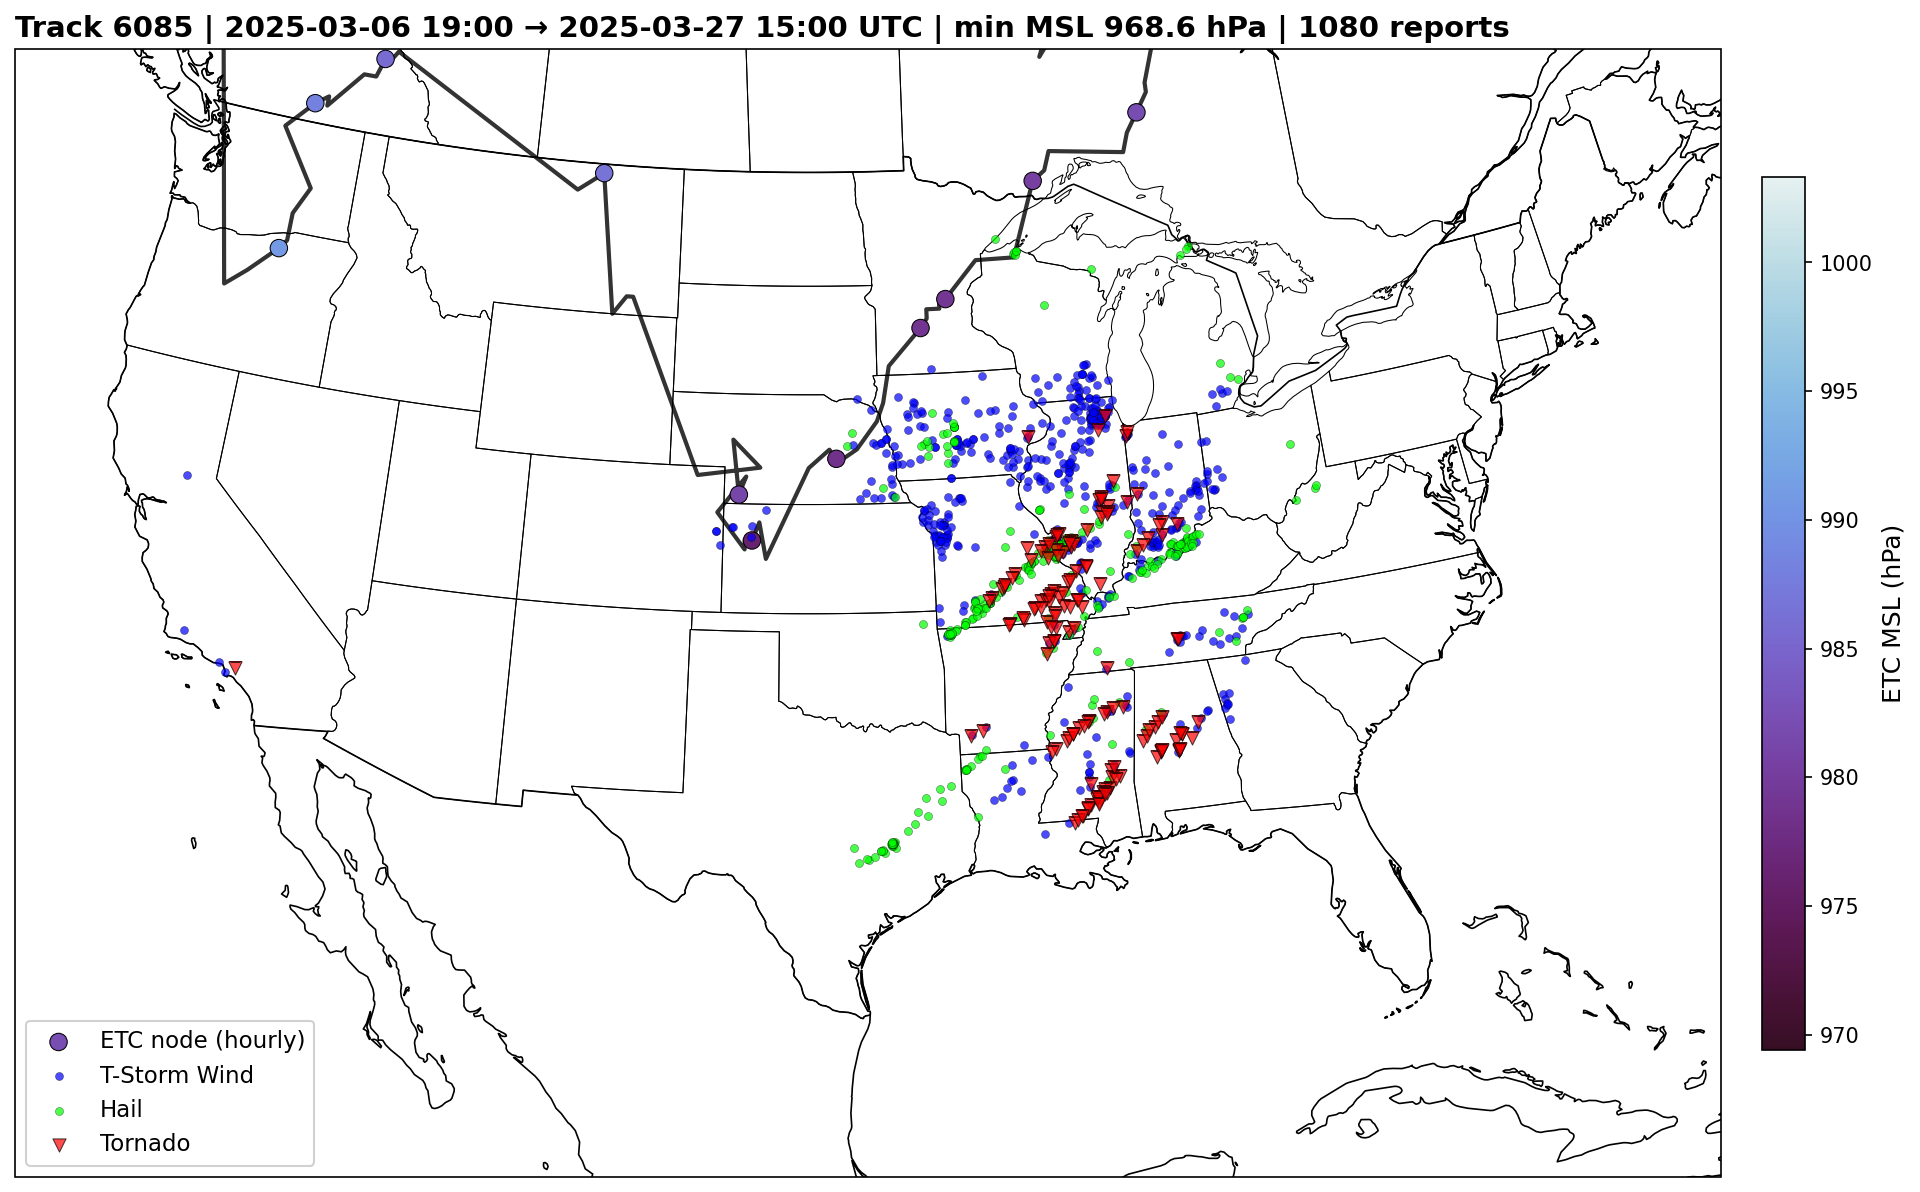

In [30]:
plot_track_case(reports_tagged, tracks_h, 6085.0, track_meta=tracks_meta)


### Plotting reports that are not associated with an ETC

In [37]:
## Kiefer proximity thresholds
MAX_DIST_KM = 2000.0
NW_DIST_KM = 500.0

# Map extent
#MAP_EXTENT = [-105, -65, 22, 52]
MAP_EXTENT = [-122.0, -72.5, 21.5, 50.0]


# Color Palette
COL = {
    "etcfree":   "#E06C1F",   # orange  — no ETC at hour
    "proxfail":  "#9F1AC7",   # purple    — ETC present, prox filter failed
    "Tornado":   "#D62728",
    "Hail":      "#2CA02C",
    "Thunderstorm Wind":      "#064DF3",
}

MARKER = {"Tornado": "^", "Hail": "s", "Thunderstorm Wind": "o"}

LABEL_REASON = {
    "etcfree":  "No ETC at hour",
    "proxfail": "ETC present, proximity filter failed",
}
LABEL_TYPE = {"Tornado": "Tornado", "Hail": "Hail", "Thunderstorm Wind": "Wind"}


In [38]:
rt = reports_tagged.copy()
assoc = rt[rt['track_id'].notna()].copy()
unassoc = rt[rt['track_id'].isna()].copy()

print(f"  Total reports      : {len(rt):,}")
print(f"  Associated         : {len(assoc):,}  ({100*len(assoc)/len(rt):.1f}%)")
print(f"  Unassociated       : {len(unassoc):,}  ({100*len(unassoc)/len(rt):.1f}%)")


  Total reports      : 81,596
  Associated         : 65,209  (79.9%)
  Unassociated       : 16,387  (20.1%)


In [39]:
## classify unassociated reports : ETC_FREE or PROX_FAIL

def classify_unassociated(unassoc_df, tracks_h):
    """
    Returns unassoc_df with a new 'reason' collumn:
        'etcfree' - no ETC existed at that hour
        'proxfail' - ETC existed but report failed the proximity filter
    
    Method: check whether the report's time_hour appears at all in the tracks_h time_hour column. If it does,
    an ETC was present. If not, there was no ETC.
    """

    th = tracks_h.copy()
    etc_hours = set(th['time_hour'].dropna().unique())

    tc = unassoc_df.copy()
    tc['reason'] = tc['time_hour'].apply(
        lambda t: 'proxfail' if t in etc_hours else 'etcfree'
    )

    return tc



In [40]:
unassoc = classify_unassociated(unassoc, tracks_h)

In [41]:
unassoc['reason'].value_counts()

reason
proxfail    15645
etcfree       742
Name: count, dtype: int64

In [43]:
def base_map(ax, extent=MAP_EXTENT):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,        facecolor="#F4F1EC", zorder=0)
    ax.add_feature(cfeature.OCEAN,       facecolor="#D6E8F5", zorder=0)
    ax.add_feature(cfeature.LAKES,       facecolor="#D6E8F5", zorder=1)
    ax.add_feature(cfeature.BORDERS,     linewidth=0.5, edgecolor="#AAAAAA", zorder=2)
    ax.add_feature(cfeature.STATES,      linewidth=0.3, edgecolor="#CCCCCC", zorder=2)
    ax.add_feature(cfeature.COASTLINE,   linewidth=0.6, edgecolor="#888888", zorder=3)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {"size": 7}
    gl.ylabel_style = {"size": 7}
    return ax

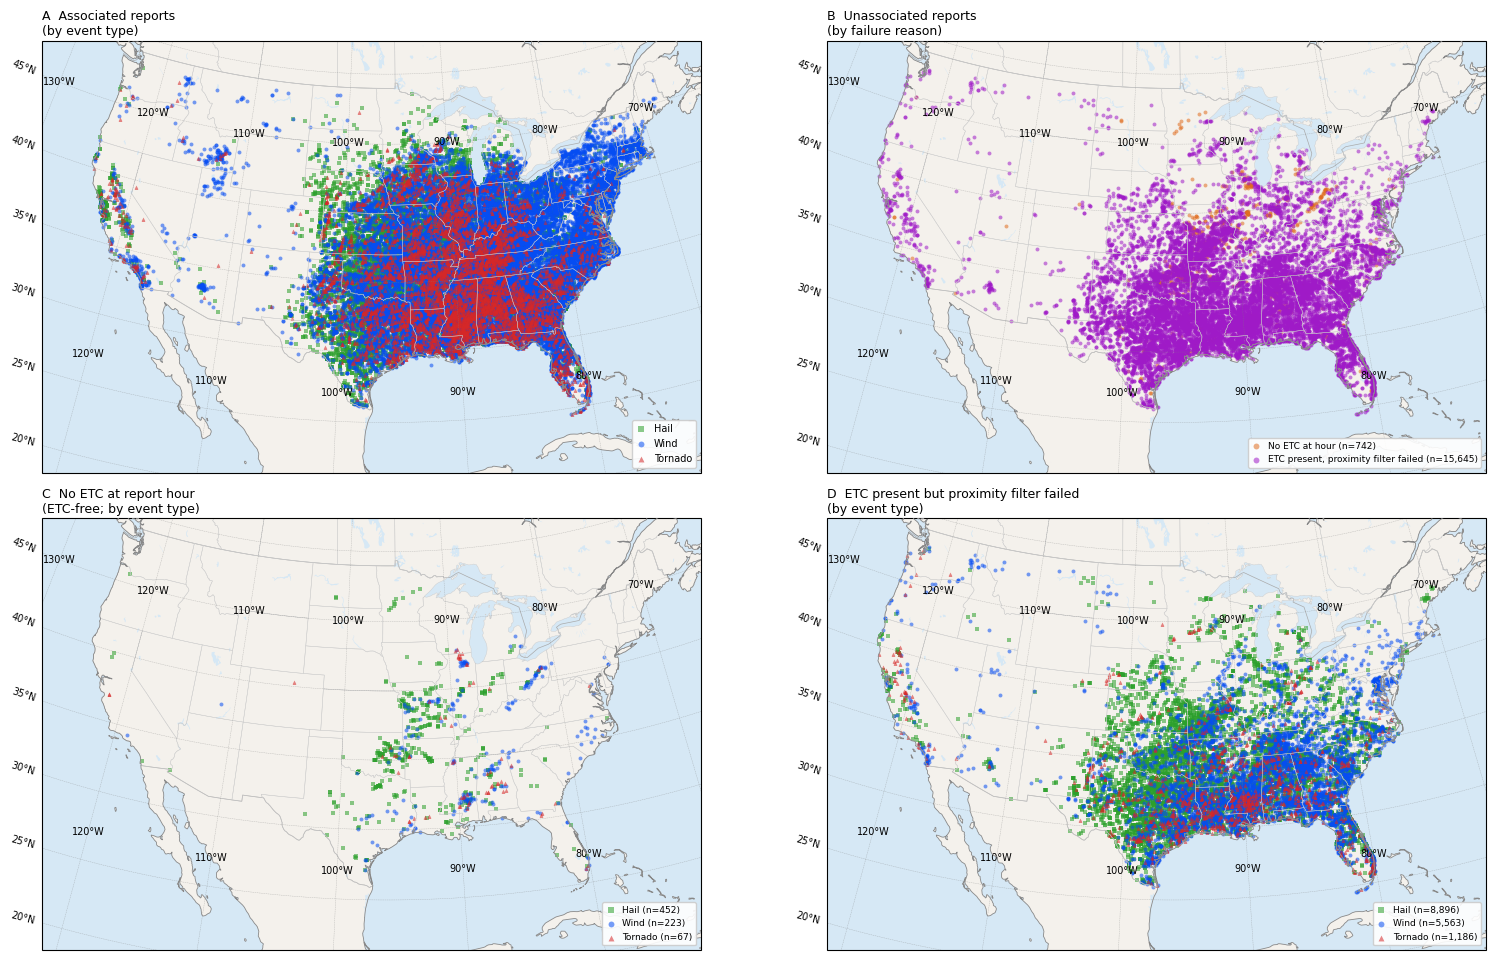

In [44]:
## Figure 1: 4-panel geographic map
##    Panel A: all associated (reference)
##    Panel B: all unassociated, coloured by reason
##    Panel C: ETC-free, by event type
##    Panel D: proximity-failed, by event type

fig, axes = plt.subplots(
    2,2,
    subplot_kw={'projection': ccrs.LambertConformal(
        #central_longitude=-95, central_latitude=37
        )},
    figsize=(16,10),
)

panel_titles = [
    "A  Associated reports\n(by event type)",
    "B  Unassociated reports\n(by failure reason)",
    "C  No ETC at report hour\n(ETC-free; by event type)",
    "D  ETC present but proximity filter failed\n(by event type)",
]

for ax, title in zip(axes.flat, panel_titles):
    base_map(ax)
    ax.set_title(title, fontsize=9, loc='left', pad=4)

# Panel A - associated, colored by event type
ax_a = axes[0,0]
for et, sub in assoc.groupby('EVENT_TYPE'):
    if et not in COL:
        continue
    ax_a.scatter(
        sub['report_lon'], sub['report_lat'],
        c=COL[et], marker=MARKER[et], s=8, alpha=0.55,
        transform = ccrs.PlateCarree(), label=LABEL_TYPE[et], linewidths=0,
    )
ax_a.legend(loc='lower right', fontsize=7, markerscale=1.5,
            framealpha=0.9, handlelength=1)

## Panel B - unassociated, colored by reason
ax_b = axes[0,1]
for reason, sub in unassoc.groupby('reason'):
    color = COL.get(reason, "#999999")
    ax_b.scatter(
        sub['report_lon'], sub['report_lat'],
        c=color, marker='o', s=8, alpha=0.55,
        transform = ccrs.PlateCarree(),
        label=f'{LABEL_REASON.get(reason, reason)} (n={len(sub):,})',
        linewidths=0,
    )
ax_b.legend(loc='lower right', fontsize=6.5, markerscale=1.5,
            framealpha=0.9, handlelength=1)

## Panels C and D - by reason, colored by event type
for (reason, ax) in [('etcfree', axes[1,0]), ('proxfail', axes[1,1])]:
    sub_reason = unassoc[unassoc['reason'] == reason]
    for et, sub in sub_reason.groupby('EVENT_TYPE'):
        if et not in COL:
            continue
        ax.scatter(
            sub['report_lon'], sub['report_lat'],
            c=COL[et], marker=MARKER[et], s=8, alpha=0.55,
            transform = ccrs.PlateCarree(), label=f'{LABEL_TYPE[et]} (n={len(sub):,})',
            linewidths=0,
        )
    ax.legend(loc='lower right', fontsize=6.5, markerscale=1.5,
              framealpha=0.9, handlelength=1)
    
plt.tight_layout(rect=[0,0,1,0.97])
#plt.savefig('unassociated_reports.png', dpi=200, bbox_inches='tight')
plt.show()
#plt.close()

In [45]:
print("Column name:", [c for c in rt.columns if 'type' in c.lower() or 'TYPE' in c])
print("\nUnique values in EVENT_TYPE:")
print(rt['EVENT_TYPE'].unique())
print("\nSample assoc rows:")
print(assoc[['EVENT_TYPE', 'report_lat', 'report_lon']].head())

Column name: ['EVENT_TYPE', 'CZ_TYPE', 'MAGNITUDE_TYPE']

Unique values in EVENT_TYPE:
['Thunderstorm Wind' 'Hail' 'Tornado']

Sample assoc rows:
          EVENT_TYPE  report_lat  report_lon
0  Thunderstorm Wind     39.8700    -83.3800
1  Thunderstorm Wind     39.9453    -82.7566
2               Hail     39.8200    -84.0100
3               Hail     39.7900    -84.0200
4               Hail     39.8100    -83.8900


In [46]:
print(unassoc['reason'].value_counts())
print(unassoc[['report_lon', 'report_lat']].isna().sum())

reason
proxfail    348
etcfree       4
Name: count, dtype: int64
report_lon    0
report_lat    0
dtype: int64


In [38]:
np.unique(unassoc['time_hour'])

array([Timestamp('2020-01-02 21:00:00+0000', tz='UTC'),
       Timestamp('2020-01-03 23:00:00+0000', tz='UTC'),
       Timestamp('2020-01-10 16:00:00+0000', tz='UTC'),
       Timestamp('2020-01-11 05:00:00+0000', tz='UTC'),
       Timestamp('2020-01-11 06:00:00+0000', tz='UTC'),
       Timestamp('2020-01-11 07:00:00+0000', tz='UTC'),
       Timestamp('2020-01-11 11:00:00+0000', tz='UTC'),
       Timestamp('2020-01-13 18:00:00+0000', tz='UTC'),
       Timestamp('2020-01-13 19:00:00+0000', tz='UTC'),
       Timestamp('2020-01-13 20:00:00+0000', tz='UTC'),
       Timestamp('2020-01-14 05:00:00+0000', tz='UTC'),
       Timestamp('2020-01-14 06:00:00+0000', tz='UTC'),
       Timestamp('2020-01-30 03:00:00+0000', tz='UTC'),
       Timestamp('2020-02-05 17:00:00+0000', tz='UTC'),
       Timestamp('2020-02-05 18:00:00+0000', tz='UTC'),
       Timestamp('2020-02-06 08:00:00+0000', tz='UTC'),
       Timestamp('2020-02-06 09:00:00+0000', tz='UTC'),
       Timestamp('2020-02-06 10:00:00+0000', tz=

## Rollups (derived)

In [36]:
DEFAULT_EVENT_TYPES = {
    "Tornado": "tornado",
    "Hail": "hail",
    "Thunderstorm Wind": "wind",
}

In [37]:
## node-level rollup
def build_nodes_with_reports(
        reports_tagged: pd.DataFrame,
        tracks_h: pd.DataFrame,
        event_types: dict[str, str] = None,
) -> pd.DataFrame:
    """
    Attach per=node report counts to every ETC node.
    Every node in tracks_h gets a row; nodes with no reports get zeros.
    This will be used as input for TempestExtremes NodeFileFilter / NodeFileCompose.

    Returns:
    nodes_with_reports: pd.DataFrame
        One row per (track_id, time_hour) with:
            lat, lon, msl,
            n_reports, n_tornado, n_hail, n_wind 
    """

    event_types = event_types or DEFAULT_EVENT_TYPES

    assoc = reports_tagged.dropna(subset=['track_id']).copy()

    ## build aggregation dict: total count + count per event type.
    agg_kwargs = {'n_reports': ('EVENT_ID','size')}
    for label, suffix in event_types.items():
        agg_kwargs[f'n_{suffix}'] = (
            'EVENT_TYPE', lambda s, lab=label: (s == lab).sum()
        )

    node_summary = (
        assoc
        .groupby(['track_id','matched_time_hour'])
        .agg(**agg_kwargs)
        .reset_index()
        .rename(columns={'matched_time_hour': 'time_hour'})
    )

    ## left merge onto ALL nodes so nodes with no reports are retained as 0s.
    fill_cols = ['n_reports'] + [f'n_{s}' for s in event_types.values()]
    nodes_with_reports = (
        tracks_h
        .merge(node_summary, on=['track_id','time_hour'], how = 'left')
        .fillna({c: 0 for c in fill_cols})
    )

    ## counts should be integers, not floats
    for c in fill_cols:
        nodes_with_reports[c] = nodes_with_reports[c].astype(int)

    return nodes_with_reports

In [38]:
## track-level rollup
def build_etc_summary(
        reports_tagged,
        track_meta,
        event_types=None,
):
    """
    Aggregate reports to one row per ETC and join lifecycle metadata. 
    This is what we join MJO/ENSO/SPV indices onto, and what we label outbreak / non-outbreak / SCS-only / scs+snow...
    """

    event_types = event_types or DEFAULT_EVENT_TYPES

    assoc = reports_tagged.dropna(subset=['track_id']).copy()

    ## build aggregation dict: total count + count per event type.
    agg_kwargs = {'n_reports': ('EVENT_ID','size')}
    for label, suffix in event_types.items():
        agg_kwargs[f'n_{suffix}'] = (
            'EVENT_TYPE', lambda s, lab=label: (s == lab).sum()
        )

    track_summary = assoc.groupby('track_id').agg(**agg_kwargs)

    ## left join onto track_meta so EVERY track appears
    etc_summary = track_meta.join(track_summary, how='left')

    ## fill report counts with -; leave distance/timecolumns as NaN
    count_cols = ['n_reports'] + [f'n_{s}' for s in event_types.values()]
    etc_summary = etc_summary.fillna({c: 0 for c in count_cols})
    for c in count_cols:
        etc_summary[c] = etc_summary[c].astype(int)

    return etc_summary

In [39]:
nodes_with_reports = build_nodes_with_reports(reports_tagged, tracks_h)

In [40]:
nodes_with_reports

,track_id,time_hour,lat,lon,msl,n_reports,n_tornado,n_hail,n_wind
0,1,2020-01-01 00:00:00+00:00,44.50,-67.00,991.6106,0,0,0,0
1,1,2020-01-01 01:00:00+00:00,44.75,-66.75,991.2206,0,0,0,0
2,1,2020-01-01 02:00:00+00:00,45.00,-66.50,991.4325,0,0,0,0
3,1,2020-01-01 03:00:00+00:00,45.25,-66.25,991.0762,0,0,0,0
4,1,2020-01-01 04:00:00+00:00,45.50,-66.00,990.5550,0,0,0,0
...,...,...,...,...,...,...,...,...,...
7235,74,2020-03-31 19:00:00+00:00,44.50,-105.25,1004.1650,0,0,0,0
7236,74,2020-03-31 20:00:00+00:00,44.50,-104.50,1003.3780,0,0,0,0
7237,74,2020-03-31 21:00:00+00:00,44.50,-103.75,1002.9580,0,0,0,0
7238,74,2020-03-31 22:00:00+00:00,43.75,-102.75,1003.1310,0,0,0,0


In [41]:
etc_summary = build_etc_summary(reports_tagged, tracks_meta)

In [42]:
etc_summary

,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind
track_id,,,,,,,,,
1.0,2020-01-01 00:00:00+00:00,2020-01-05 22:00:00+00:00,2020-01-05 03:00:00+00:00,956.5094,115,0,0,0,0
2.0,2020-01-01 11:00:00+00:00,2020-01-04 04:00:00+00:00,2020-01-01 19:00:00+00:00,986.4200,59,0,0,0,0
3.0,2020-01-02 13:00:00+00:00,2020-01-06 23:00:00+00:00,2020-01-03 23:00:00+00:00,975.0175,102,0,0,0,0
4.0,2020-01-03 11:00:00+00:00,2020-01-08 23:00:00+00:00,2020-01-08 10:00:00+00:00,990.7425,133,0,0,0,0
5.0,2020-01-04 00:00:00+00:00,2020-01-06 18:00:00+00:00,2020-01-06 15:00:00+00:00,951.6381,62,2,2,0,0
...,...,...,...,...,...,...,...,...,...
69.0,2020-03-23 17:00:00+00:00,2020-03-31 23:00:00+00:00,2020-03-25 19:00:00+00:00,992.0688,197,0,0,0,0
70.0,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137,465,24,266,175
72.0,2020-03-30 00:00:00+00:00,2020-03-31 23:00:00+00:00,2020-03-31 23:00:00+00:00,1000.3920,38,113,16,0,97


In [65]:
pwd

'/home1/lepique/circs_research'

## Save outputs to CSV files:

In [43]:
reports_tagged.to_csv('reports_tagged_2.csv', index=False)
nodes_with_reports.to_csv('nodes_with_reports_2.csv', index=False)
etc_summary.to_csv('etc_summary_2.csv', index=True)

In [2]:
reports_tagged = pd.read_csv('reports_tagged.csv')

In [3]:
reports_tagged

,EVENT_ID,time_hour,report_lat,report_lon,EVENT_TYPE,BEGIN_DT_UTC,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,...,dist_km,rlon,rlat,track_start,track_end,time_min_msl,min_msl,n_steps,lifecycle_frac,hours_from_min_msl
0,874472,2020-03-28 18:00:00+00:00,39.8700,-83.3800,Thunderstorm Wind,2020-03-28 17:32:00+00:00,202003,28,1332,202003,...,1053.545100,12.3700,-1.1300,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137.0,0.630137,-4.0
1,874474,2020-03-28 18:00:00+00:00,39.9453,-82.7566,Thunderstorm Wind,2020-03-28 17:57:00+00:00,202003,28,1357,202003,...,1104.283251,12.9934,-1.0547,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137.0,0.630137,-4.0
2,874475,2020-03-28 17:00:00+00:00,39.8200,-84.0100,Hail,2020-03-28 17:17:00+00:00,202003,28,1317,202003,...,1042.062256,12.2400,-0.6800,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137.0,0.623288,-5.0
3,874476,2020-03-28 17:00:00+00:00,39.7900,-84.0200,Hail,2020-03-28 17:18:00+00:00,202003,28,1318,202003,...,1041.691817,12.2300,-0.7100,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137.0,0.623288,-5.0
4,874477,2020-03-28 17:00:00+00:00,39.8100,-83.8900,Hail,2020-03-28 17:26:00+00:00,202003,28,1326,202003,...,1052.365790,12.3600,-0.6900,2020-03-24 22:00:00+00:00,2020-03-31 00:00:00+00:00,2020-03-28 22:00:00+00:00,990.4569,137.0,0.623288,-5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2770,873664,2020-01-13 20:00:00+00:00,35.2347,-78.1000,Thunderstorm Wind,2020-01-13 19:32:00+00:00,202001,13,1432,202001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2771,873665,2020-01-13 20:00:00+00:00,35.2700,-78.0400,Thunderstorm Wind,2020-01-13 19:39:00+00:00,202001,13,1439,202001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2772,866687,2020-01-11 08:00:00+00:00,32.8654,-92.5633,Tornado,2020-01-11 08:19:00+00:00,202001,11,219,202001,...,342.673997,-1.3133,-2.8846,2020-01-11 08:00:00+00:00,2020-01-14 13:00:00+00:00,2020-01-14 13:00:00+00:00,978.8231,77.0,0.000000,-77.0
2773,873657,2020-01-12 06:00:00+00:00,35.7399,-78.2567,Thunderstorm Wind,2020-01-12 05:36:00+00:00,202001,12,36,202001,...,735.376056,2.7433,-6.2601,2020-01-11 08:00:00+00:00,2020-01-14 13:00:00+00:00,2020-01-14 13:00:00+00:00,978.8231,77.0,0.285714,-55.0
